Imports and Data Loading

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("/content/train.csv")
test_text = pd.read_csv("/content/test.csv")
test_labels = pd.read_csv("/content/test_labels.csv")

test_df = pd.merge(test_text, test_labels, on='id')
test_df = test_df[test_df['toxic'] != -1].reset_index(drop=True)

print("Размер тренировочной выборки:", train_df.shape)
print("Размер тестовой выборки:", test_df.shape)
display(train_df.head())

Размер тренировочной выборки: (159571, 8)
Размер тестовой выборки: (63978, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


Checking for Missing Values

In [9]:
print("Missing values per column:")
print(train_df.isnull().sum())

Missing values per column:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


Class Distribution Analysis

/tmp/ipykernel_11995/4253740573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


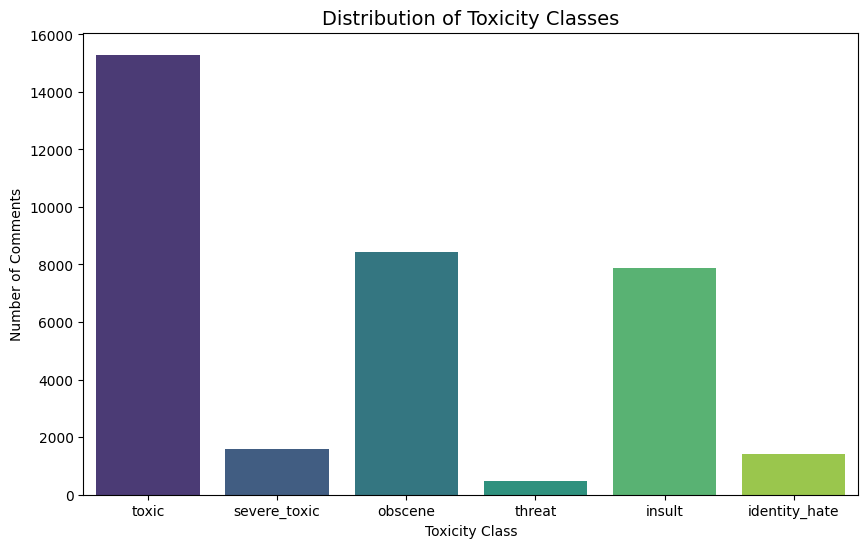

Insight: The dataset is highly imbalanced. Most toxic comments fall into the 'toxic' and 'obscene' categories, while 'threat' is extremely rare.


In [12]:
# List of our target labels
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Count the number of occurrences for each label
label_counts = train_df[labels].sum()

# Plotting the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title('Distribution of Toxicity Classes', fontsize=14)
plt.ylabel('Number of Comments')
plt.xlabel('Toxicity Class')
plt.show()

print("Insight: The dataset is highly imbalanced. Most toxic comments fall into the 'toxic' and 'obscene' categories, while 'threat' is extremely rare.")

Clean vs. Toxic Comments

In [13]:
# Create a column to flag comments that have no toxic labels (clean comments)
train_df['is_clean'] = (train_df[labels].sum(axis=1) == 0).astype(int)

clean_count = train_df['is_clean'].sum()
toxic_count = len(train_df) - clean_count

print(f"Clean comments: {clean_count} ({clean_count/len(train_df)*100:.1f}%)")
print(f"Toxic comments: {toxic_count} ({toxic_count/len(train_df)*100:.1f}%)")

Clean comments: 143346 (89.8%)
Toxic comments: 16225 (10.2%)
